# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar imágenes de personajes de la conocida serie de los Simpsons.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en imágenes de personajes de los Simpsons extraídas directamente de capítulos de la serie. Este dataset ha sido recopilado por [Alexandre Attia](http://www.alexattia.fr/) y es más complejo que el dataset de Fashion MNIST que hemos utilizado hasta ahora. Aparte de tener más clases (vamos a utilizar los 18 personajes con más imágenes), los personajes pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros personajes en pantalla (si bien el personaje a clasificar siempre aparece en la posición predominante).

El dataset de training puede ser descargado desde aquí:

[Training data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60) (~500MB)

Por otro lado, el dataset de test puede ser descargado de aquí:

[Test data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8) (~10MB)

Antes de empezar la práctica, se recomienda descargar las imágenes y echarlas un vistazo.


## Carga de los datos

In [ ]:
#instalación de keras preprocessing
!pip install keras-preprocessing

In [ ]:
import cv2
import os
import numpy as np
import keras
import matplotlib.pyplot as plt
import glob
import tensorflow as tf
from tensorflow import keras

#agregado
import random
import pandas as pd




In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
from keras.models import load_model
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay #plot_confusion_matrix has been deprecated
plt.rcParams["figure.figsize"] = (20,6)

#Agregado
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import EfficientNetB4, MobileNetV2, NASNetMobile, Xception, ResNet50V2
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad
from keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras import layers
from tensorflow.keras import Model
from keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

In [ ]:
# Primero, bajamos los datos de entrenamiento
keras.utils.get_file(fname="simpsons_train.tar.gz",
                     origin="https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60")

# Descomprimimos el archivo
!tar -xzf /root/.keras/datasets/simpsons_train.tar.gz -C /root/.keras/datasets


# Hacemos lo mismo con los datos de test
keras.utils.get_file(fname="simpsons_test.tar.gz",
                     origin="https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8")
!tar -xzf /root/.keras/datasets/simpsons_test.tar.gz -C /root/.keras/datasets

523789527/523789527 ━━━━━━━━━━━━━━━━━━━━ 33s 0us/step
10658925/10658925 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# Descomprimimos el archivo en tmp para visualizar
# !tar -xzf /root/.keras/datasets/simpsons_train.tar.gz -C /tmp/simpsons

In [ ]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes
IMG_SIZE = 71

In [ ]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintas, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels de correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [ ]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)


In [ ]:
# Cargamos los datos. Si no estás trabajando en colab, cambia los paths por
# los de los ficheros donde hayas descargado los datos.
DATASET_TRAIN_PATH_COLAB = "/root/.keras/datasets/simpsons"
DATASET_TEST_PATH_COLAB = "/root/.keras/datasets/simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


In [ ]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

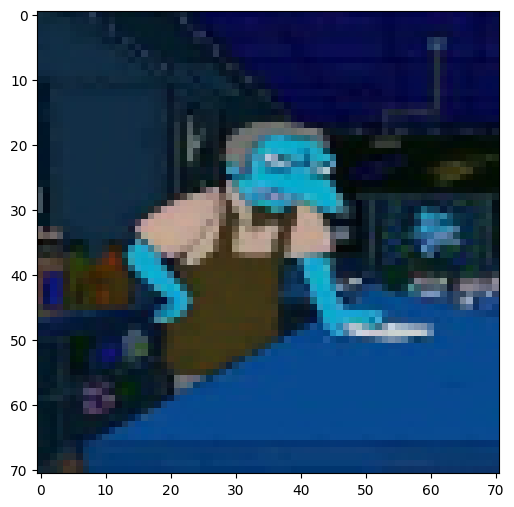

In [ ]:
plt.imshow(X_t[2])

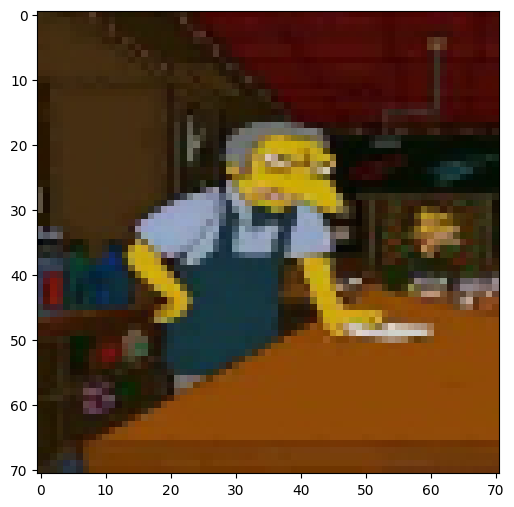

In [ ]:
#Change image to RGB
plt.imshow(np.flip(X_t[2], axis=-1) )

## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer personajes en imágenes de los Simpsons con una accuracy en el dataset de test de, al menos, **85%**. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos para ser analizados en vuestro informe:

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes o qué personajes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Recuerda partir los datos en training/validation para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 80 / 20.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.
* Las imágenes **no están normalizadas**. Hay que normalizarlas como hemos hecho en trabajos anteriores.
* El test set del problema tiene imágenes un poco más "fáciles", por lo que es posible encontrarse con métricas en el test set bastante mejores que en el training set.

## Funciones para trabajar

In [ ]:
#Función para graficar resultados del performance del modelo
def PlotPerformance(acc, val_acc, loss, val_loss, name_exp):
    accuracy = acc
    val_accuracy = val_acc
    loss_model = loss
    val_loss_model = val_loss
    Accname = f'{name_exp} Accuracy'
    Lossname = f'{name_exp} Loss'

    epochs = range(len (accuracy))

    #------------------------------------------------
    # Accuracy
    #------------------------------------------------

    plt.plot(epochs, accuracy,'b',label='Training accuracy')
    plt.plot(epochs, val_accuracy,'r',label='Validation accuracy')
    plt.title(Accname)
    plt.legend()
    plt.figure()

    #------------------------------------------------
    # Loss
    #------------------------------------------------

    plt.plot(epochs, loss_model, 'b', label='Training Loss')
    plt.plot(epochs, val_loss_model, 'r', label='Validation Loss')
    plt.title(Lossname)
    plt.legend()
    plt.show()

In [ ]:
#Función para graficar resultados del performance del modelo
def PlotPerformance(acc, val_acc, loss, val_loss, name_exp):
    accuracy = acc
    val_accuracy = val_acc
    loss_model = loss
    val_loss_model = val_loss
    Accname = f'{name_exp} Accuracy'
    Lossname = f'{name_exp} Loss'

    epochs = range(len (accuracy))

    #------------------------------------------------
    # Accuracy
    #------------------------------------------------

    plt.plot(epochs, accuracy,'b',label='Training accuracy')
    plt.plot(epochs, val_accuracy,'r',label='Validation accuracy')
    plt.title(Accname)
    plt.legend()
    plt.figure()

    #------------------------------------------------
    # Loss
    #------------------------------------------------

    plt.plot(epochs, loss_model, 'b', label='Training Loss')
    plt.plot(epochs, val_loss_model, 'r', label='Validation Loss')
    plt.title(Lossname)
    plt.legend()
    plt.show()

In [ ]:
#Funcion para mostrár imágenes
def display_images(set_img, y_label, num_rows, num_cols):

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(9, 9))
    axes = axes.ravel()

    for i in range(len(set_img)):
        plt.tight_layout()
        img = cv2.cvtColor(set_img[i], cv2.COLOR_BGR2RGB)
        # Desplegar la imagen en la retícula
        ax = plt.subplot(num_rows, num_cols, i + 1)
        ax.title.set_text(str(MAP_CHARACTERS[y_label[i]]))
        plt.imshow(img)
        plt.axis('off')

In [ ]:
# callback para detener el entrenamiento al alcanzar el 90% de accuracy
class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')> 0.90):
              print("\nAlcanzado el 90% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

## Visualización de algunas imágenes

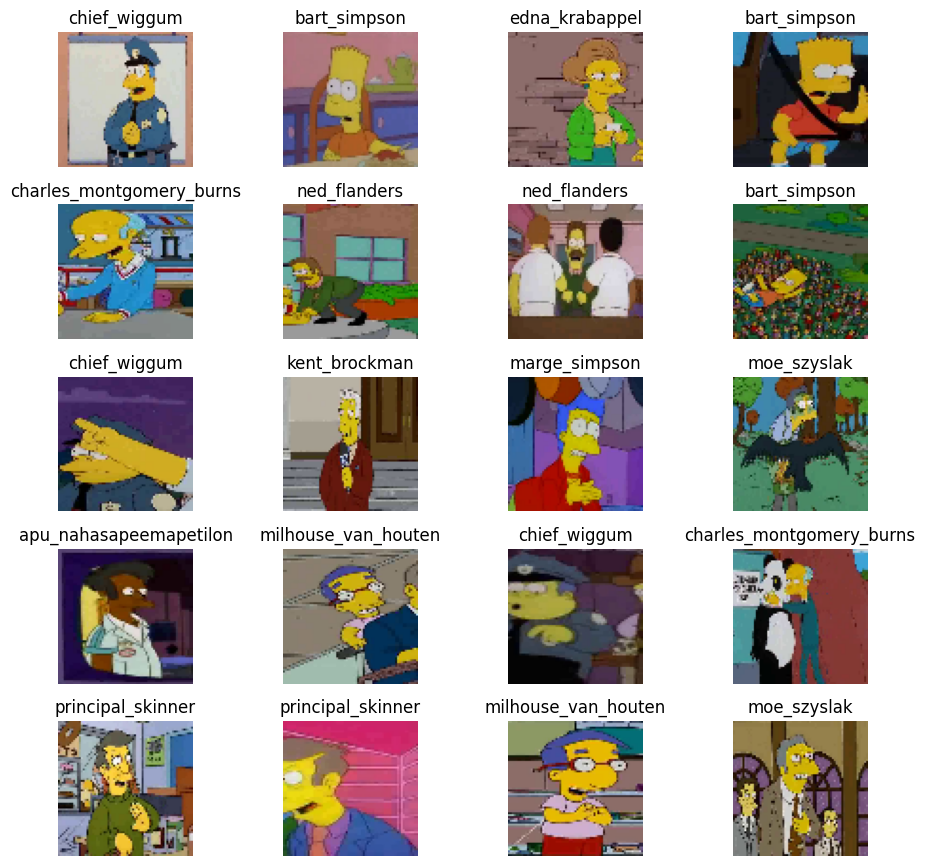

In [ ]:
# Obtención de imágenes random
idx_sample = random.sample(range(0, 18991), 20)

display_images(X[idx_sample], y[idx_sample], 5, 4)

Elementos train set


Text(0, 0.5, 'Frecuencia')

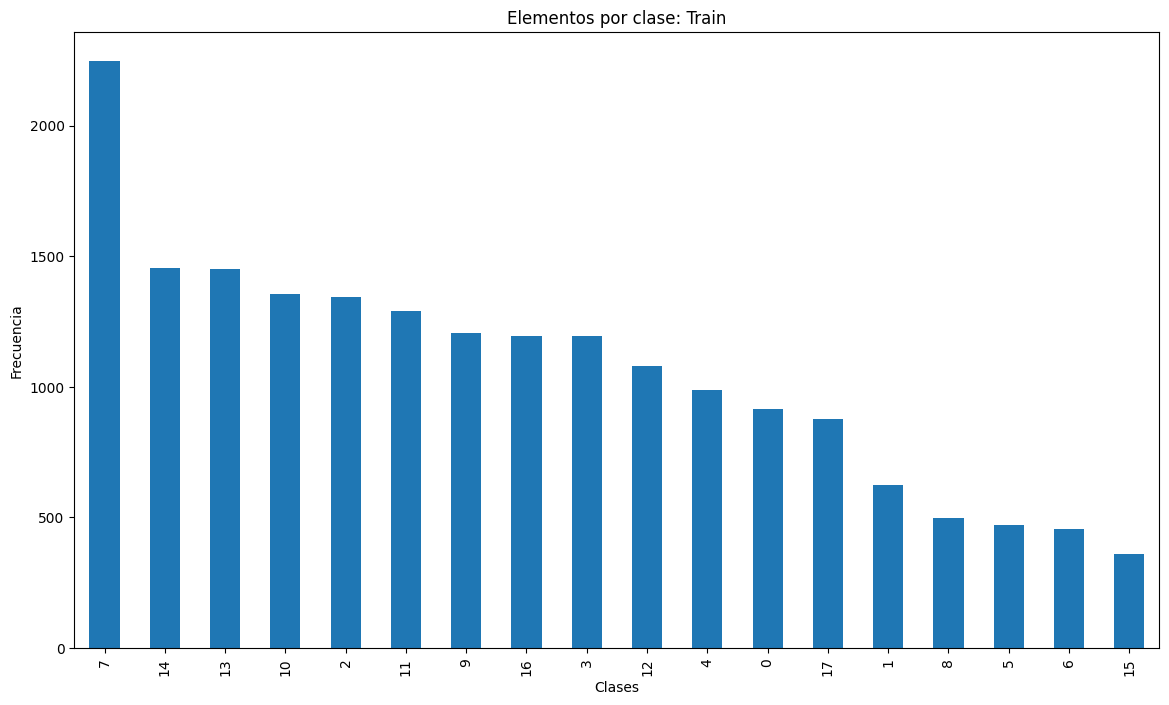

In [ ]:
print("Elementos train set")
ax = pd.Series(list(y)).value_counts().plot(kind='bar',
                                    figsize=(14,8),
                                    title="Elementos por clase: Train")
ax.set_xlabel("Clases")
ax.set_ylabel("Frecuencia")

In [ ]:
# imagenes para entrenamiento y validacion
X_train, X_valid, y_train, y_valid = train_test_split(X, y,
                                                    stratify=y,
                                                    test_size=0.2)

In [ ]:
# normalizacion de las imagenes
X_train = X_train / 255.0
X_valid = X_valid / 255.0
X_test = X_t / 255.0

Elementos train set final


Text(0, 0.5, 'Frecuencia')

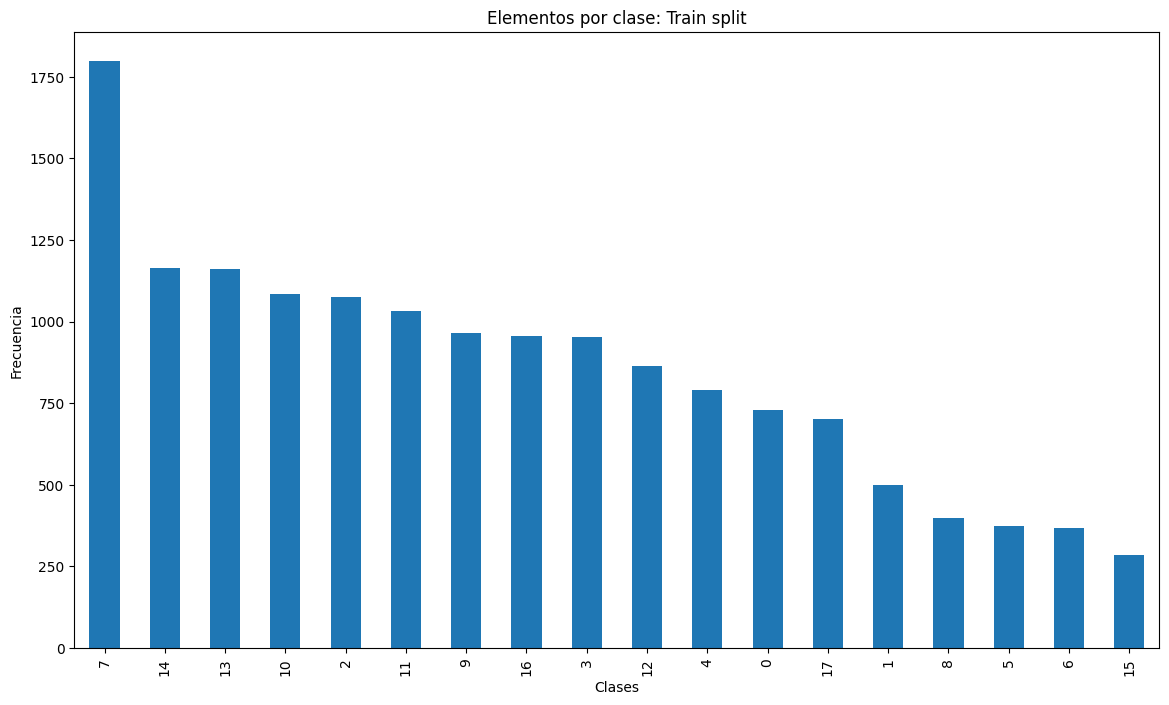

In [ ]:
print("Elementos train set final")
ax = pd.Series(list(y_train)).value_counts().plot(kind='bar',
                                    figsize=(14,8),
                                    title="Elementos por clase: Train split")
ax.set_xlabel("Clases")
ax.set_ylabel("Frecuencia")

Elementos final validation set


Text(0, 0.5, 'Frecuencia')

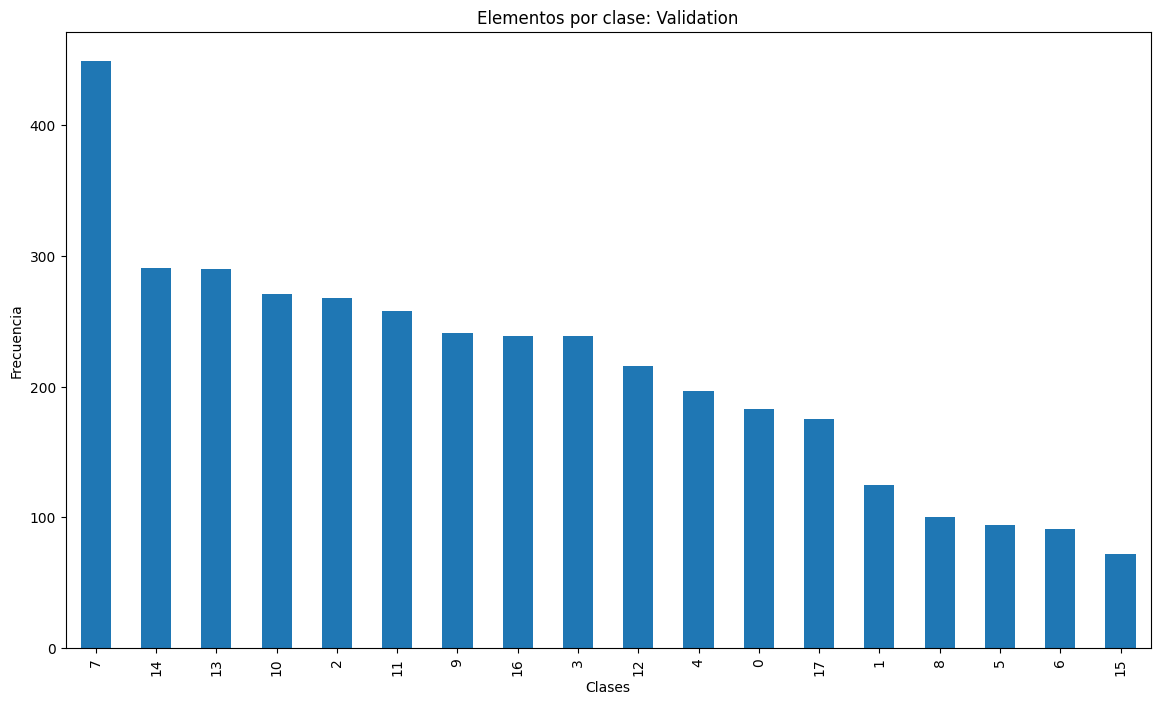

In [ ]:
print("Elementos final validation set")
ax = pd.Series(list(y_valid)).value_counts().plot(kind='bar',
                                    figsize=(14,8),
                                    title="Elementos por clase: Validation")
ax.set_xlabel("Clases")
ax.set_ylabel("Frecuencia")

## Implementación de augmentation

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generar las imágenes aumentadas en tiempo real
train_generator = datagen.flow(
    X_train, y_train,
    batch_size=32
)

## Implementación de modelo propio

In [ ]:
# definimos el modelo propio, propuesto por Justin
modelo_propio_justin = Sequential()
# primera capa convolucional
modelo_propio_justin.add(Input(shape=(60, 60, 3)))
modelo_propio_justin.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(MaxPooling2D((2, 2)))
modelo_propio_justin.add(Dropout(0.10))

# segunda capa convolucional
modelo_propio_justin.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(MaxPooling2D((2, 2)))
modelo_propio_justin.add(Dropout(0.14))

# tercera capa convolucional
modelo_propio_justin.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(MaxPooling2D((2, 2)))
modelo_propio_justin.add(Dropout(0.16))

# capa fully conected y salida
modelo_propio_justin.add(Flatten())
modelo_propio_justin.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(Dropout(0.20))
modelo_propio_justin.add(Dense(18, activation='softmax'))

In [ ]:
class_weights_sk = class_weight.compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(y_train),
    y = y_train
)
class_weights_sk = dict(zip(set(y_train), class_weights_sk))
class_weights_sk

{0: 1.1562404870624048,
 1: 1.6948906738063365,
 2: 0.7858990275191392,
 3: 0.8847542511064523,
 4: 1.0697789043796648,
 5: 2.250814814814815,
 6: 2.3061627200971464,
 7: 0.4697025907376492,
 8: 2.120742601898381,
 9: 0.8746689694876223,
 10: 0.7793680106699498,
 11: 0.8170915349037324,
 12: 0.9780481524398095,
 13: 0.7263817173455728,
 14: 0.7257571414923092,
 15: 2.951243201243201,
 16: 0.8838278068644561,
 17: 1.20235834124723}

In [ ]:
modelo_propio_justin.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 60, 60, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 60, 60, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 60, 60, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 60, 60, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 30, 30, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 30, 30, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 30, 30, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 30, 30, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 15, 15, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 15, 15, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 15, 15, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 3,509,810 (13.39 MB)

 Trainable params: 3,508,914 (13.39 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,
    decay_rate=0.9)

In [ ]:
# optimizadores
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True) # este es el que mejor ha funcionado
adam_optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)



In [ ]:
# ajustamos el learning_rate

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Supervisar la pérdida en el conjunto de validación
    factor=0.1,  # Reducir el learning rate en un factor de 10
    patience=3,  # Si no mejora en 3 épocas
    min_lr=1e-6  # Límite inferior del learning rate
)

In [ ]:
# configuramos el EarlyStop

early_stopping = EarlyStopping(
    monitor='val_accuracy',  # Supervisar la precisión en el conjunto de validación
    patience=6,  # Parar si no mejora después de 5 épocas
    restore_best_weights=True  # Usar los mejores pesos logrados durante el entrenamiento
)

In [ ]:
#compilamos el modelo
modelo_propio_justin.compile(optimizer=sgd_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
#Definición del callback
callbacks = myCallback()

modelo_propio_entrenado = modelo_propio_justin.fit(
                     train_generator,
                     epochs=100,
                     validation_data=(X_valid, y_valid),
                     callbacks=[callbacks, early_stopping, reduce_lr],
                     batch_size = 32,
                     verbose = 2,
                     class_weight=class_weights_sk)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


475/475 - 39s - 81ms/step - accuracy: 0.2125 - loss: 4.0604 - val_accuracy: 0.3340 - val_loss: 3.4795 - learning_rate: 0.0100
Epoch 2/100
475/475 - 20s - 43ms/step - accuracy: 0.3247 - loss: 3.4590 - val_accuracy: 0.4491 - val_loss: 3.0345 - learning_rate: 0.0100
Epoch 3/100
475/475 - 19s - 41ms/step - accuracy: 0.4307 - loss: 2.9903 - val_accuracy: 0.5525 - val_loss: 2.5938 - learning_rate: 0.0100
Epoch 4/100
475/475 - 20s - 42ms/step - accuracy: 0.5287 - loss: 2.5542 - val_accuracy: 0.5257 - val_loss: 2.5732 - learning_rate: 0.0100
Epoch 5/100
475/475 - 19s - 40ms/step - accuracy: 0.6002 - loss: 2.2212 - val_accuracy: 0.6546 - val_loss: 2.0407 - learning_rate: 0.0100
Epoch 6/100
475/475 - 20s - 43ms/step - accuracy: 0.6650 - loss: 1.9497 - val_accuracy: 0.6828 - val_loss: 1.9158 - learning_rate: 0.0100
Epoch 7/100
475/475 - 19s - 39ms/step - accuracy: 0.7134 - loss: 1.7307 - val_accuracy: 0.7465 - val_loss: 1.7039 - learning_rate: 0.0100
Epoch 8/100
475/475 - 20s - 43ms/step - accura

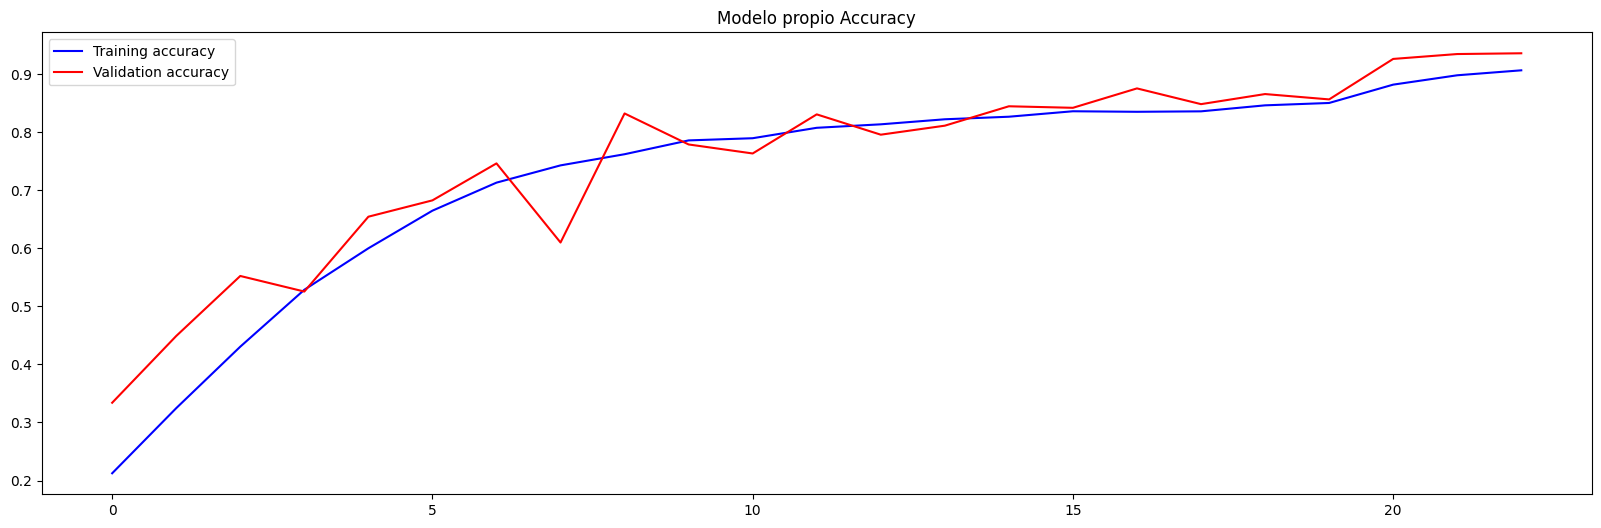

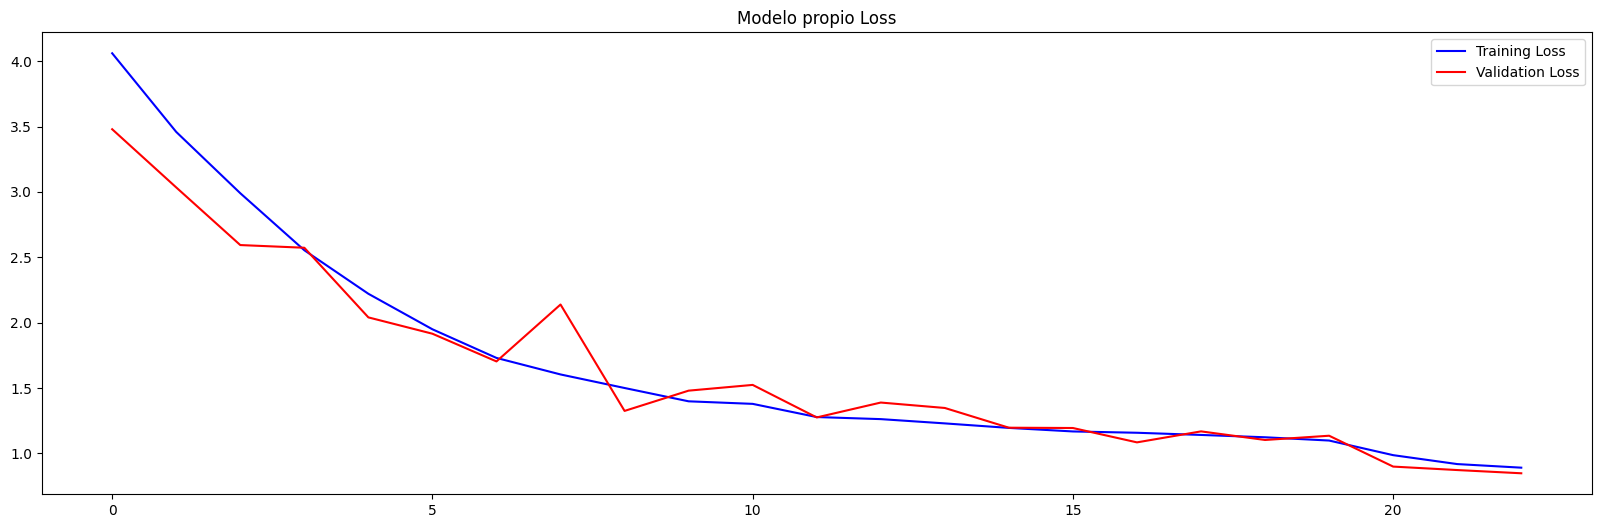

In [ ]:
PlotPerformance(modelo_propio_entrenado.history['accuracy'],
                modelo_propio_entrenado.history['val_accuracy'],
                modelo_propio_entrenado.history['loss'],
                modelo_propio_entrenado.history['val_loss'],
                'Modelo propio')

In [ ]:
#Creación de lista de personajes
list_caracters = list(MAP_CHARACTERS.values())

In [ ]:
# hacemos una prediccion con el conjunto de test para evaluar resultados
y_pred = modelo_propio_justin.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_t, y_pred, target_names=list_caracters))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.98      0.92      0.95        48
  apu_nahasapeemapetilon       1.00      1.00      1.00        50
            bart_simpson       0.86      0.98      0.92        50
charles_montgomery_burns       0.98      0.90      0.93        48
            chief_wiggum       0.98      0.96      0.97        50
          comic_book_guy       0.96      0.96      0.96        49
          edna_krabappel       0.98      0.98      0.98        50
           homer_simpson       0.90      0.92      0.91        50
           kent_brockman       0.98      1.00      0.99        50
        krusty_the_clown       0.98      1.00      0.99        50
            lisa_simpson       0.93      0.86      0.90        50
           marge_simpson       1.00      0.98      0.99        50
     milhouse_van_houten       1.00      1.00      1.00        49
             moe_szyslak       0.96

## Craeción de modelo basado en EfficientNetB4

In [ ]:
pre_trained_model = EfficientNetB4(weights='imagenet',
                                  include_top=False,
                                  input_shape=(60, 60, 3))

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# hacemos que las capas de pre_trained_model no sean entrenables
for layer in pre_trained_model.layers:
  layer.trainable = False

In [ ]:
# agregamos una ultima capa fully conected al modelo pre entrenado

rms_optimizer = RMSprop(learning_rate=0.01, rho=0.9)
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
adam_optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
adagrad_optimizer = Adagrad(learning_rate=0.01)
# aplanamos la salida del modelo
x = layers.GlobalAveragePooling2D()(pre_trained_model.output)
x = layers.Flatten()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.12)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
# x = layers.Dense(64, activation='relu')(X)
# Add a final sigmoid layer for classification
x = layers.Dense(18, activation='sigmoid')(x)

model = Model(pre_trained_model.input, x)

model.compile(optimizer=rms_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# entrenamos nuestro nuevo modelo
modelo_preentrenado_1 = model.fit(train_generator,
                    epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[callbacks, early_stopping, reduce_lr],
                    batch_size = 32,
                    verbose = 2,
                    class_weight=class_weights_sk)

Epoch 1/100
475/475 - 118s - 248ms/step - accuracy: 0.0423 - loss: 4.0850 - val_accuracy: 0.0713 - val_loss: 2.8877 - learning_rate: 0.0100
Epoch 2/100
475/475 - 23s - 49ms/step - accuracy: 0.0512 - loss: 2.8929 - val_accuracy: 0.0461 - val_loss: 2.8914 - learning_rate: 0.0100
Epoch 3/100
475/475 - 23s - 48ms/step - accuracy: 0.0471 - loss: 2.8929 - val_accuracy: 0.0629 - val_loss: 2.8924 - learning_rate: 0.0100
Epoch 4/100
475/475 - 24s - 50ms/step - accuracy: 0.0476 - loss: 2.8930 - val_accuracy: 0.0461 - val_loss: 2.8892 - learning_rate: 0.0100
Epoch 5/100
475/475 - 25s - 52ms/step - accuracy: 0.0462 - loss: 2.8915 - val_accuracy: 0.0461 - val_loss: 2.8876 - learning_rate: 1.0000e-03
Epoch 6/100
475/475 - 24s - 51ms/step - accuracy: 0.0462 - loss: 2.8910 - val_accuracy: 0.0461 - val_loss: 2.8871 - learning_rate: 1.0000e-03
Epoch 7/100
475/475 - 23s - 49ms/step - accuracy: 0.0454 - loss: 2.8909 - val_accuracy: 0.0461 - val_loss: 2.8871 - learning_rate: 1.0000e-03


## Craeción de modelo basado en MobileNetV2

In [ ]:
# MobileNetV2, NASNetMobile, Xception, ResNet50V2
pre_trained_model_2 = MobileNetV2(
    input_shape = (60, 60, 3),
    include_top = False,
    weights = 'imagenet')

<ipython-input-57-4fa0572b711a>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  pre_trained_model_2 = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
 # hacemos modelo con fine tuning
for layer in pre_trained_model_2.layers:
  layer.trainable = True

# resumen de la arquitectura pre entrenada
#pre_trained_model_2.summary()

# optimizadores
rms_optimizer = RMSprop(learning_rate=0.01, rho=0.9)
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
adam_optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
adagrad_optimizer = Adagrad(learning_rate=0.01)


# aplanamos la salida del modelo
x = layers.GlobalAveragePooling2D()(pre_trained_model_2.output)
x = layers.Flatten()(x)
# Add a fully connected layer with 1,024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.12)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
# Add a final sigmoid layer for classification
x = layers.Dense(18, activation='sigmoid')(x)

modelMobile = Model(pre_trained_model_2.input, x)

modelMobile.compile(optimizer=adagrad_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

modelo_preentrenado_2 = modelMobile.fit(train_generator,
                    epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[myCallback(), early_stopping, reduce_lr],
                    batch_size = 32,
                    verbose = 2,
                    class_weight=class_weights_sk)

Epoch 1/100
475/475 - 94s - 197ms/step - accuracy: 0.1137 - loss: 2.6984 - val_accuracy: 0.0853 - val_loss: 5.8831 - learning_rate: 0.0100
Epoch 2/100
475/475 - 23s - 48ms/step - accuracy: 0.3683 - loss: 1.8875 - val_accuracy: 0.3077 - val_loss: 3.5833 - learning_rate: 0.0100
Epoch 3/100
475/475 - 23s - 49ms/step - accuracy: 0.5595 - loss: 1.3258 - val_accuracy: 0.4056 - val_loss: 2.9057 - learning_rate: 0.0100
Epoch 4/100
475/475 - 22s - 46ms/step - accuracy: 0.6654 - loss: 1.0424 - val_accuracy: 0.5415 - val_loss: 2.0053 - learning_rate: 0.0100
Epoch 5/100
475/475 - 23s - 47ms/step - accuracy: 0.7210 - loss: 0.8778 - val_accuracy: 0.6678 - val_loss: 1.2806 - learning_rate: 0.0100
Epoch 6/100
475/475 - 23s - 49ms/step - accuracy: 0.7515 - loss: 0.7680 - val_accuracy: 0.6883 - val_loss: 1.1807 - learning_rate: 0.0100
Epoch 7/100
475/475 - 22s - 46ms/step - accuracy: 0.7761 - loss: 0.6949 - val_accuracy: 0.7486 - val_loss: 0.9587 - learning_rate: 0.0100
Epoch 8/100
475/475 - 23s - 48ms/

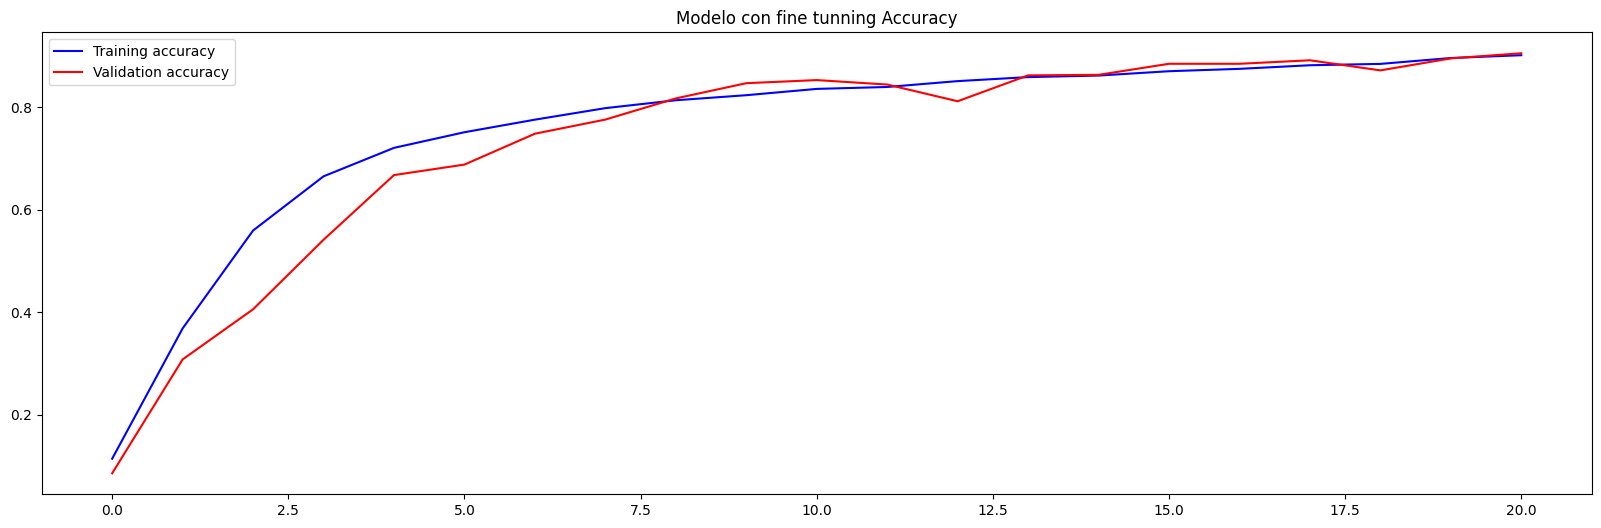

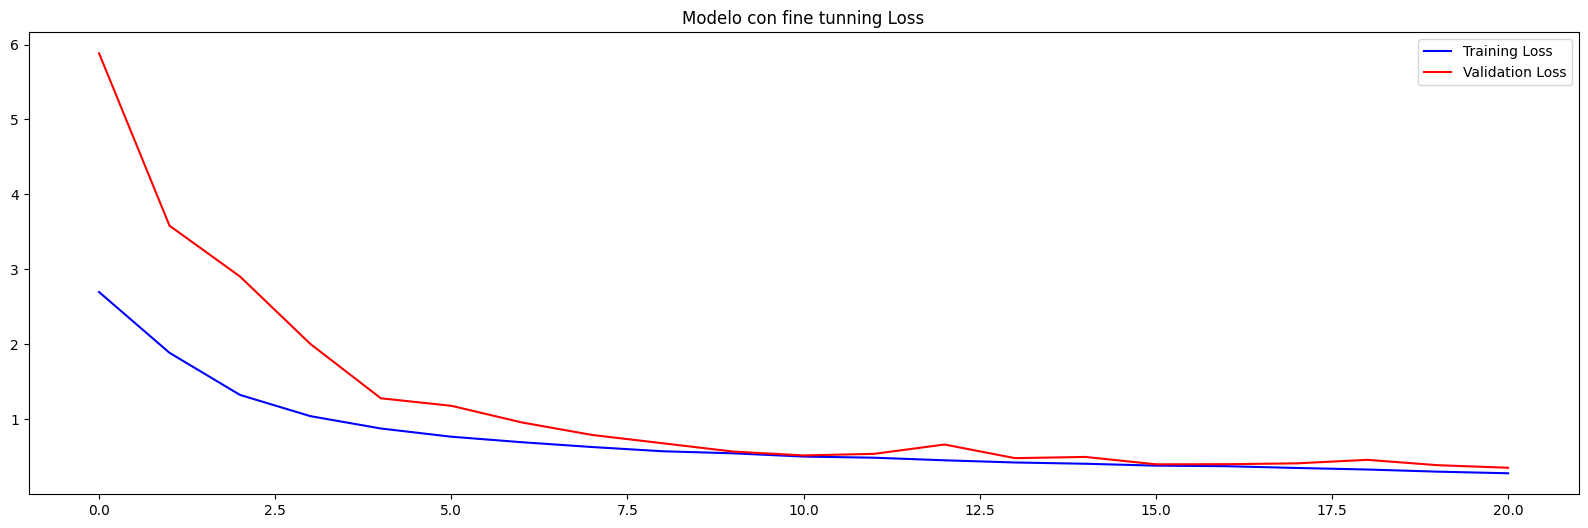

In [ ]:
PlotPerformance(modelo_preentrenado_2.history['accuracy'],
                modelo_preentrenado_2.history['val_accuracy'],
                modelo_preentrenado_2.history['loss'],
                modelo_preentrenado_2.history['val_loss'],
                'Modelo con fine tunning')

In [ ]:
# hacemos una prediccion con el conjunto de test para evaluar resultados
y_pred = modelMobile.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_t, y_pred, target_names=list_caracters))

NameError: name 'modelMobile' is not defined

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_valid, y_pred)

print(classification_report(y_valid, y_pred))


## Craeción de modelo basado en NASNetMobile

In [ ]:
# MobileNetV2, NASNetMobile, Xception, ResNet50V2
pre_trained_model_3 = NASNetMobile(
    input_shape = (60, 60, 3),
    include_top = False,
    weights = 'imagenet')


In [ ]:
# segundo modelo con fine tuning
for layer in pre_trained_model_3.layers[300:]:
  layer.trainable = True

# resumen de la arquitectura pre entrenada
#pre_trained_model_3.summary()

# # optimizadores
rms_optimizer = RMSprop(learning_rate=0.01, rho=0.9)
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
adam_optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
adagrad_optimizer = Adagrad(learning_rate=0.01)


# aplanamos la salida del modelo
x = layers.GlobalAveragePooling2D()(pre_trained_model_3.output)
x = layers.Flatten()(x)
# Add a fully connected layer with 1,024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.12)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
# Add a final sigmoid layer for classification
x = layers.Dense(18, activation='sigmoid')(x)

modelNas = Model(pre_trained_model_3.input, x)

modelNas.compile(optimizer=adagrad_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

modelo_preentrenado_3 = modelNas.fit(train_generator,
                    epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[myCallback(), early_stopping, reduce_lr],
                    batch_size = 32,
                    verbose = 2,
                    class_weight=class_weights_sk)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


475/475 - 278s - 584ms/step - accuracy: 0.0860 - loss: 2.7963 - val_accuracy: 0.0884 - val_loss: 4.1079 - learning_rate: 0.0100
Epoch 2/100
475/475 - 40s - 85ms/step - accuracy: 0.3130 - loss: 2.1107 - val_accuracy: 0.1553 - val_loss: 3.2678 - learning_rate: 0.0100
Epoch 3/100
475/475 - 40s - 85ms/step - accuracy: 0.5332 - loss: 1.4356 - val_accuracy: 0.1445 - val_loss: 4.1690 - learning_rate: 0.0100
Epoch 4/100
475/475 - 40s - 85ms/step - accuracy: 0.6427 - loss: 1.1357 - val_accuracy: 0.2688 - val_loss: 3.0591 - learning_rate: 0.0100
Epoch 5/100
475/475 - 41s - 86ms/step - accuracy: 0.6929 - loss: 0.9758 - val_accuracy: 0.2859 - val_loss: 3.2082 - learning_rate: 0.0100
Epoch 6/100
475/475 - 41s - 85ms/step - accuracy: 0.7226 - loss: 0.8607 - val_accuracy: 0.3601 - val_loss: 2.6370 - learning_rate: 0.0100
Epoch 7/100
475/475 - 40s - 85ms/step - accuracy: 0.7571 - loss: 0.7685 - val_accuracy: 0.4443 - val_loss: 2.1456 - learning_rate: 0.0100
Epoch 8/100
475/475 - 40s - 85ms/step - accu

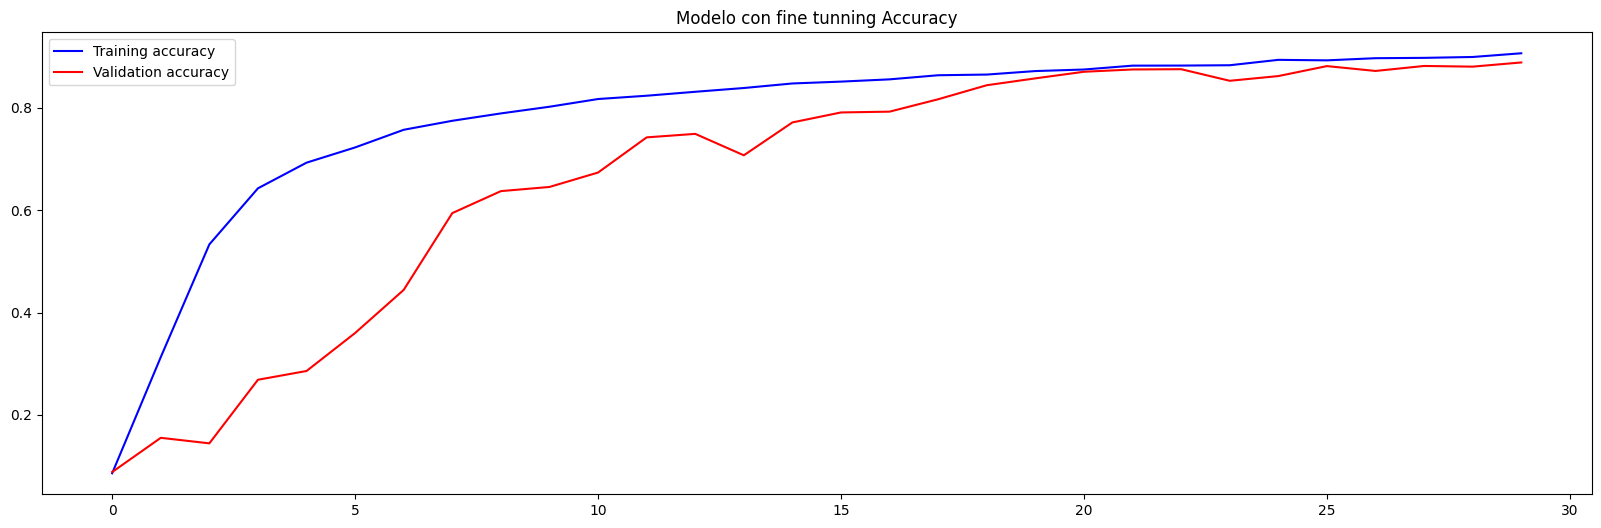

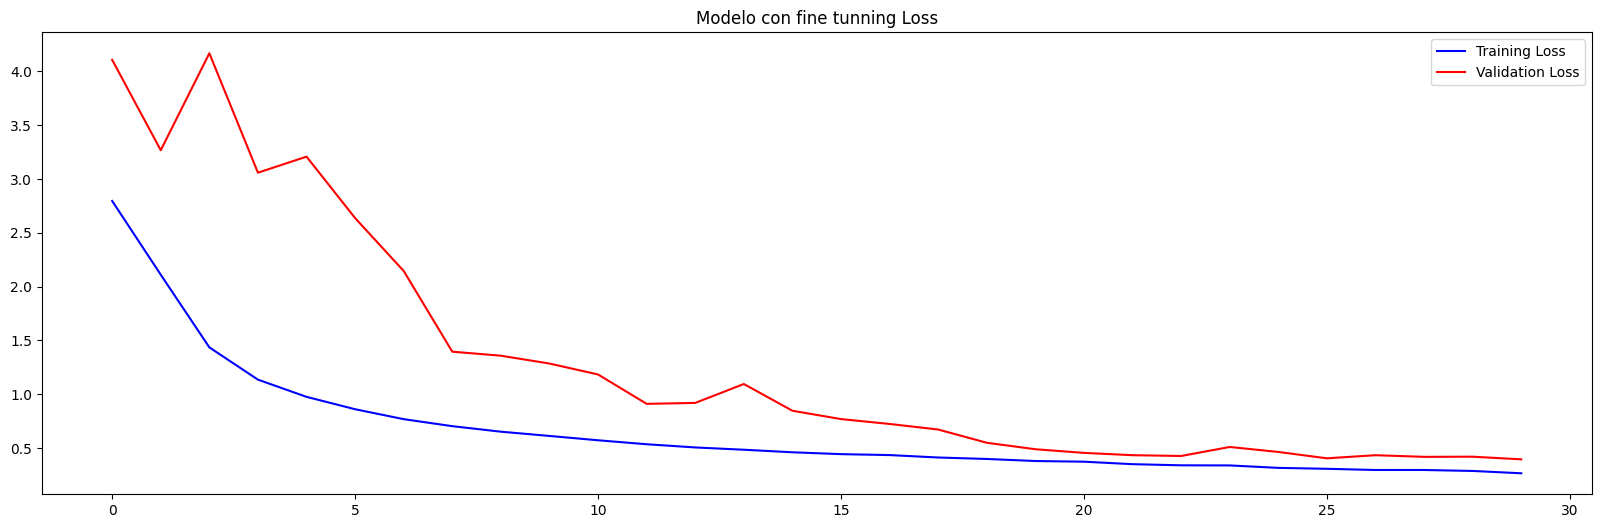

In [ ]:
PlotPerformance(modelo_preentrenado_3.history['accuracy'],
                modelo_preentrenado_3.history['val_accuracy'],
                modelo_preentrenado_3.history['loss'],
                modelo_preentrenado_3.history['val_loss'],
                'Modelo con fine tunning')

In [ ]:
# hacemos una prediccion con el conjunto de test para evaluar resultados
y_pred = modelNas.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_t, y_pred, target_names=list_caracters))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.83      0.92      0.87        48
  apu_nahasapeemapetilon       0.98      0.98      0.98        50
            bart_simpson       0.94      0.98      0.96        50
charles_montgomery_burns       0.93      0.90      0.91        48
            chief_wiggum       0.96      1.00      0.98        50
          comic_book_guy       0.98      0.96      0.97        49
          edna_krabappel       0.92      0.98      0.95        50
           homer_simpson       0.90      0.92      0.91        50
           kent_brockman       0.98      0.98      0.98        50
        krusty_the_clown       1.00      1.00      1.00        50
            lisa_simpson       0.98      0.84      0.90        50
           marge_simpson       0.98      1.00      0.99        50
     milhouse_van_houten       0.96      0.96      0.96        49
             moe_szyslak       0.96

## Craeción de modelo basado en ResNet50V2

In [ ]:
# MobileNetV2, NASNetMobile, Xception, ResNet50V2
pre_trained_model_4 = ResNet50V2(
    input_shape = (60, 60, 3),
    include_top = False,
    weights = 'imagenet')


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# segundo modelo con fine tuning
for layer in pre_trained_model_4.layers[300:]:
  layer.trainable = True

# resumen de la arquitectura pre entrenada
#pre_trained_model_3.summary()

# # optimizadores
rms_optimizer = RMSprop(learning_rate=0.01, rho=0.9)
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
adam_optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
adagrad_optimizer = Adagrad(learning_rate=0.01)


# aplanamos la salida del modelo
x = layers.GlobalAveragePooling2D()(pre_trained_model_4.output)
x = layers.Flatten()(x)
# Add a fully connected layer with 1,024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.12)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
# Add a final sigmoid layer for classification
x = layers.Dense(18, activation='sigmoid')(x)

modelRes = Model(pre_trained_model_4.input, x)

modelRes.compile(optimizer=adagrad_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

modelo_preentrenado_4 = modelRes.fit(train_generator,
                    epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[myCallback(), early_stopping, reduce_lr],
                    batch_size = 32,
                    verbose = 2,
                    class_weight=class_weights_sk)


Epoch 1/100


KeyboardInterrupt: 

In [ ]:
PlotPerformance(modelo_preentrenado_4.history['accuracy'],
                modelo_preentrenado_4.history['val_accuracy'],
                modelo_preentrenado_4.history['loss'],
                modelo_preentrenado_4.history['val_loss'],
                'Modelo con fine tunning')

In [ ]:
# hacemos una prediccion con el conjunto de test para evaluar resultados
y_pred = modelNas.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_t, y_pred, target_names=list_caracters))

## Craeción de modelo basado en Xception

In [ ]:
# MobileNetV2, NASNetMobile, Xception, ResNet50V2
pre_trained_model_5 = Xception(
    input_shape = (71, 71, 3),
    include_top = False,
    weights = 'imagenet')


In [ ]:
# segundo modelo con fine tuning
for layer in pre_trained_model_5.layers[300:]:
  layer.trainable = True

# resumen de la arquitectura pre entrenada
#pre_trained_model_5.summary()

# # optimizadores
rms_optimizer = RMSprop(learning_rate=0.01, rho=0.9)
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
adam_optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
adagrad_optimizer = Adagrad(learning_rate=0.01)


# aplanamos la salida del modelo
x = layers.GlobalAveragePooling2D()(pre_trained_model_5.output)
x = layers.Flatten()(x)
# Add a fully connected layer with 1,024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.12)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
# Add a final sigmoid layer for classification
x = layers.Dense(18, activation='sigmoid')(x)

modelxce = Model(pre_trained_model_5.input, x)

modelxce.compile(optimizer=adagrad_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

modelo_preentrenado_5 = modelxce.fit(train_generator,
                    epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[myCallback(), early_stopping, reduce_lr],
                    batch_size = 32,
                    verbose = 2,
                    class_weight=class_weights_sk)


Epoch 1/100


KeyboardInterrupt: 

In [ ]:
PlotPerformance(modelo_preentrenado_5.history['accuracy'],
                modelo_preentrenado_5.history['val_accuracy'],
                modelo_preentrenado_5.history['loss'],
                modelo_preentrenado_5.history['val_loss'],
                'Modelo con fine tunning')

In [ ]:
# hacemos una prediccion con el conjunto de test para evaluar resultados
y_pred = modelxce.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_t, y_pred, target_names=list_caracters))

Algunos modelos no pudieron correr por falta de recursos, pero de los que se pudieron correr, el que presentó el mejor resultado fue el modelo MobileNetV2 debido a que alcanzó el 90% de precisión en la menor cantidad de intentos. Esto también lo podemos determinar al ver las gráficas de precisión en donde se puede observar que los comportamientos entre la precisión del entrenamiento y la de validación son similares.

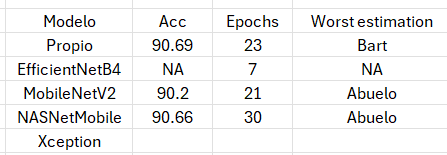

En la mayoría de los casos, no se presentó overfitting en el sentido de que tanto el entrenamiento como la validación se encuentran en porcentajes similares. La excepción sería el modelo basado en EfficientNetB4 en donde no se lograba progreso. Gracias al parámetro de paciencia, no se continuó con los intentos puesto que cada época no generaba progreso.

En cuestión de los personajes, varía el resultado. Esto puede deverse a que los sets de entrenamiento no contaron con suficientes "muestras" de algún personaje en particular. Aunque puede que esta no sea la única causa. Otro motivo para que el modelo batalle con ciertos personajes puede ser la variabilidad de las propias imágenes, es decir, el personaje está en diversas poses por lo que resulta más complejo encontrar patrones.